# GAN test

In [24]:
import sys
sys.path.append("..")
import numpy as np
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels = 1),
    transforms.ToTensor()
])

dataset = datasets.MNIST(root = "./data", download = True, transform = transform)

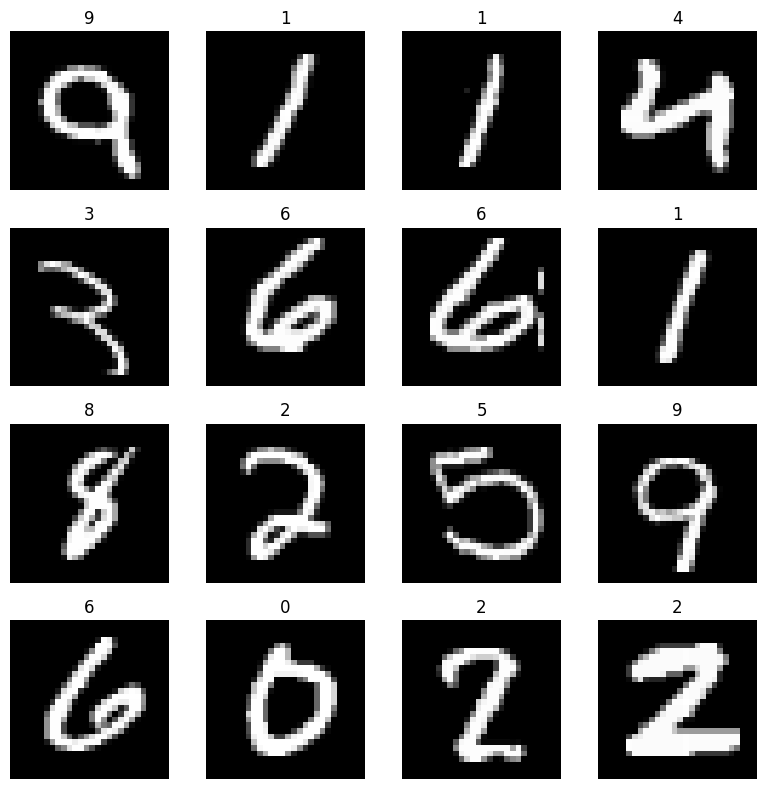

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    image, label = dataset[np.random.randint(0, len(dataset))]
    image = image[0]
    ax.imshow(image, cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [26]:
image_dim = image.shape[0] * image.shape[1]
image_dim

784

In [155]:
from fnn import FNN
import torch
from torch import nn
from utils import device

latent_dim = 128

class Generator(nn.Module):
    def __init__(self, latent_dim: int) -> None:
        super().__init__()
        self._proj = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.LayerNorm(128 * 7 * 7),
            nn.LeakyReLU(),
        )
        self._net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size = 4, stride = 2, padding = 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, 64, kernel_size = 4, stride = 2, padding = 1),  
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Conv2d(64, 1, kernel_size = 5, stride = 1, padding = 2),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        h = self._proj(z)
        h = h.view(z.shape[0], 128, 7, 7)
        return (self._net(h) + 1) / 2

class Discriminator(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self._net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size = 4, stride = 2, padding = 1),
            nn.LeakyReLU(),
            nn.Conv2d(64, 64, kernel_size = 4, stride = 2, padding = 1),
            nn.LeakyReLU(),
            nn.Conv2d(64, 64, kernel_size = 5, stride = 1, padding = 2),
            nn.LeakyReLU(),
        )
        self._fc = nn.Sequential(
            nn.Linear(64 * 49, 2048),
            nn.LayerNorm(2048),
            nn.LeakyReLU(),
            nn.LayerNorm(2048),
            nn.Linear(2048, 1024),
            nn.LeakyReLU(),
            nn.LayerNorm(1024),
            nn.Linear(1024, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self._net(x)
        x = x.flatten(start_dim = 1)
        return self._fc(x)

gen = Generator(latent_dim = latent_dim).to(device)
gen_optimizer = torch.optim.Adam(gen.parameters(), lr = 2e-4, betas = (0.5, 0.999))
disc = Discriminator().to(device)
disc_optimizer = torch.optim.Adam(disc.parameters(), lr = 2e-4, betas = (0.5, 0.999))

In [156]:
from torch.utils.data import DataLoader
from torch.nn.utils import clip_grad_norm_
from tqdm import tqdm, trange

batch_size = 128
num_epochs = 200

dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = True, drop_last = True)
bce_loss_with_logits = nn.BCEWithLogitsLoss()
gen.train()
disc.train()
...

Ellipsis

In [157]:
i = 0
for epoch in trange(num_epochs):
    for batch_idx, (real_images, _) in enumerate(dataloader):
        real_images = real_images.to(device)
        
        disc_optimizer.zero_grad(set_to_none = True)
        with torch.no_grad():
            fake_images = gen(torch.randn(batch_size, latent_dim, device = device))
        images = torch.cat([real_images, fake_images])
        output = disc(images)
        target = torch.cat([torch.ones_like(output[: batch_size]), torch.zeros_like(output[batch_size :])])
        disc_loss = bce_loss_with_logits(output, target)
        disc_loss.backward()
        clip_grad_norm_(disc.parameters(), max_norm = 1.0)
        disc_optimizer.step()

        for _ in range(3):
            gen_optimizer.zero_grad(set_to_none = True)
            fake_images = gen(torch.randn(batch_size, latent_dim, device = device))
            output = disc(fake_images)
            gen_loss = bce_loss_with_logits(output, torch.ones_like(output))
            gen_loss.backward()
            clip_grad_norm_(gen.parameters(), max_norm = 1.0)
            gen_optimizer.step()

        i += 1
        if i % 100 == 0:
            print(f"{i}, g: {gen_loss.item():.4f}, d: {disc_loss.item():.4f}")

  0%|          | 0/200 [00:00<?, ?it/s]

100, g: 1.2049, d: 0.6454
200, g: 1.2143, d: 0.6096
300, g: 1.2072, d: 0.3691
400, g: 1.9670, d: 0.3542


  0%|          | 1/200 [00:43<2:23:46, 43.35s/it]

500, g: 1.8521, d: 0.3358
600, g: 2.1873, d: 0.3137
700, g: 2.3612, d: 0.4246
800, g: 2.1588, d: 0.3742


  0%|          | 1/200 [01:55<6:23:10, 115.53s/it]


KeyboardInterrupt: 

In [1]:
fig, axes = plt.subplots(4, 4, figsize = (8, 8))

gen.eval()
with torch.no_grad():
    fake_images = gen(torch.randn(16, latent_dim, device = device))

for i, ax in enumerate(axes.flatten()):
    image = fake_images[i, 0].cpu()
    ax.imshow(image, cmap = 'gray')
    ax.axis('off')

gen.train()
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

# Modular GAN test

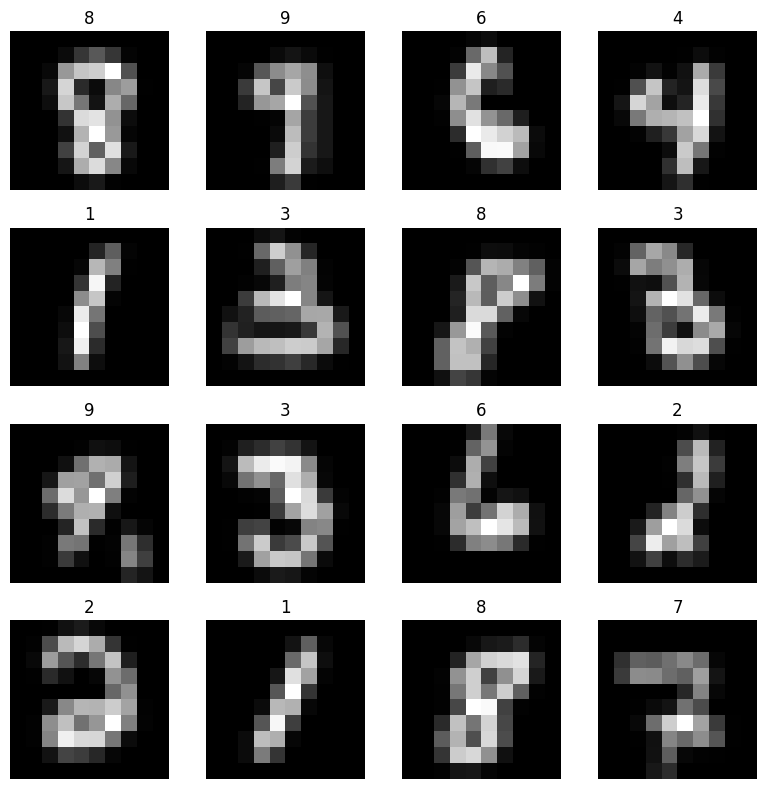

In [1]:
import sys
sys.path.append("..")
import numpy as np
from modular_network import ModularNetwork
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((10, 10)),
    transforms.Grayscale(num_output_channels = 1),
    transforms.ToTensor(),
])

dataset = datasets.MNIST(root = "./data", download = True, transform = transform)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    image, label = dataset[np.random.randint(0, len(dataset))]
    image = image[0]
    ax.imshow(image, cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [2]:
from torch import nn, optim
from utils import RangedTanh, device

image_dim = image.shape[0] * image.shape[1]
latent_dim = 128
rng = np.random.default_rng(1)

gen = ModularNetwork(
    input_dim = latent_dim,
    embed_dim = 1024,
    num_hidden_layers = 8,
    num_encoders = 2,
    tree_depth = 2,
    fan_in = 2,
    output_dim = image_dim,
    rng = rng,
    output_activation = RangedTanh(0, 1),
).to(device)

disc = ModularNetwork(
    input_dim = image_dim,
    embed_dim = 512,
    num_hidden_layers = 5,
    num_encoders = 2,
    tree_depth = 2,
    fan_in = 2,
    output_dim = 1,
    rng = rng,
).to(device)

gen_optimizer = optim.Adam(gen.parameters(), lr = 3e-4)
disc_optimizer = optim.Adam(disc.parameters(), lr = 3e-4)

In [3]:
import torch
from torch.utils.data import DataLoader
from torch.nn.utils import clip_grad_norm_
from tqdm import tqdm, trange

batch_size = 128
num_epochs = 200
gen_polyak_factor = 0.005
disc_polyak_factor = 0.1

dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = True, drop_last = True)
bce_loss_with_logits = nn.BCEWithLogitsLoss()

In [ ]:
gen.train()
disc.train()
i = 0
for epoch in trange(num_epochs):
    for batch_idx, (real_images, _) in enumerate(dataloader):
        real_images = real_images.flatten(start_dim = 1).to(device)
        
        disc_optimizer.zero_grad(set_to_none = True)
        training_module_id = disc.get_random_module_id()
        module_id = gen.get_random_module_id()
        with torch.no_grad():
            latent_vectors = torch.randn(batch_size, latent_dim, device = device)
            fake_images = gen.forward(latent_vectors).flatten(start_dim = 1)
        images = torch.cat([real_images, fake_images])
        output = disc.forward(images, online_module_id = training_module_id)
        target = torch.cat([torch.full_like(output[: batch_size], .9), torch.zeros_like(output[batch_size :])])
        disc_loss = bce_loss_with_logits(output, target)
        disc_loss.backward()
        clip_grad_norm_(disc.parameters(), max_norm = 1.0)
        disc_optimizer.step()
        disc.polyak_update(module_id = training_module_id, polyak_factor = disc_polyak_factor)
        disc_optimizer.zero_grad(set_to_none = True)

        for _ in range(50):
            gen_optimizer.zero_grad(set_to_none = True)
            training_module_id = gen.get_random_module_id()
            live_encoder_id = disc.get_random_encoder_id()
            latent_vectors = torch.randn(batch_size, latent_dim, device = device)
            fake_images = gen.forward(latent_vectors, online_module_id = training_module_id).flatten(start_dim = 1)
            diversity = (fake_images[0] - fake_images[1]).norm(p = 1)
            output = disc(fake_images)
            gen_loss = bce_loss_with_logits(output, torch.ones_like(output))
            gen_loss.backward()
            clip_grad_norm_(gen.parameters(), max_norm = 1.0)
            gen_optimizer.step()
            gen.polyak_update(module_id = training_module_id, polyak_factor = gen_polyak_factor)
        gen_optimizer.zero_grad(set_to_none = True)

        i += 1
        if i % 5 == 0:
            print(f"{i}, g: {gen_loss.item():.6f}, d: {disc_loss.item():.6f}, r: {diversity.item():.6f}")

NameError: name 'gen' is not defined

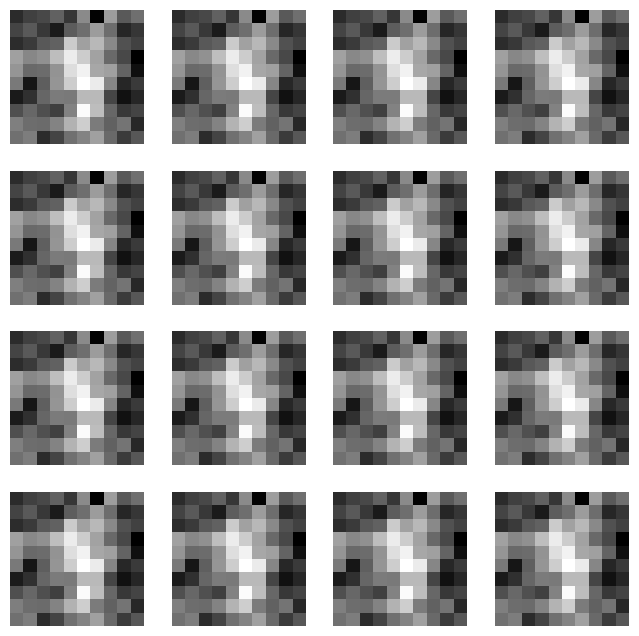

In [11]:
gen.eval()
with torch.no_grad():
    latent_vectors = torch.randn(16, latent_dim, device = device)
    fake_images = gen(torch.randn(16, latent_dim, device = device))
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    image = fake_images[i].cpu()
    image = image.view(int(np.sqrt(image_dim)), int(np.sqrt(image_dim)))
    ax.imshow(image, cmap='gray')
    ax.axis('off')

In [6]:
import numpy as np
import torch
import torch.optim as optim
from torch.nn.functional import mse_loss
from tqdm import trange
from fnn import FNN
from modular_network import ModularNetwork

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng = np.random.default_rng(42)

net = ModularNetwork(
    input_dim = 4,
    embed_dim = 128,
    num_hidden_layers = 5,
    num_encoders = 4,
    tree_depth = 3,
    fan_in = 2,
    output_dim = 1,
    rng = rng,
).to(device)

optimizer = optim.Adam(net.parameters(), lr=1e-3)
polyak_factor = 0.01

for step in trange(20000):
    x = torch.rand(64, 4, device=device)
    target = x.abs().pow(2.5).sum(dim=-1, keepdim=True).pow(1/2.5)

    module_id = net.get_random_module_id()
    optimizer.zero_grad(set_to_none=True)
    pred = net.forward(x, online_module_id=module_id)
    loss = mse_loss(pred, target)
    loss.backward()
    optimizer.step()
    net.polyak_update(module_id=module_id, polyak_factor=polyak_factor)

    if step % 1000 == 0:
        with torch.no_grad():
            pred_eval = net.forward(x)
            eval_loss = mse_loss(pred_eval, target)
        print(f"step {step}, train loss: {loss.item():.6f}, eval loss: {eval_loss.item():.6f}")

with torch.no_grad():
    x_test = torch.rand(1024, 4, device=device)
    target_test = x_test.abs().pow(2.5).sum(dim=-1, keepdim=True).pow(1/2.5)
    final_loss = mse_loss(net.forward(x_test), target_test)
print(f"final eval loss: {final_loss.item():.6f}")
assert final_loss < 1e-3, f"failed: {final_loss.item()}"

  0%|          | 11/20000 [00:00<10:02, 33.20it/s] 

step 0, train loss: 0.861005, eval loss: 0.852654


  2%|▏         | 374/20000 [00:03<03:25, 95.69it/s] 


KeyboardInterrupt: 

In [ ]:
import torch
from torch import Tensor, nn, optim
from tqdm import trange
from fnn import FNN
from utils import RangedTanh, device

image_dim  = 100
latent_dim = 128

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self._fc = nn.Linear(latent_dim, 128 * 5 * 5)
        self._net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1),  # 5x5
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 10x10
            nn.LeakyReLU(),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),             # 10x10
            RangedTanh(0, 1),
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self._fc(x)
        x = x.view(-1, 128, 5, 5)   # reshape to spatial
        x = self._net(x)
        return x.flatten(start_dim=1)  # flatten back to image_dim
        

gen = Generator().to(device)

gen = FNN(
    input_size        = latent_dim,
    hidden_size       = 512,
    num_hidden_layers = 4,
    output_size       = image_dim,
    output_activation = RangedTanh(0, 1),
    dropout_rate      = 0.1,
    layer_norm        = True,
).to(device)

critic = FNN(
    input_size        = image_dim,
    hidden_size       = 512,
    num_hidden_layers = 5,
    output_size       = 1,
    spectral_norm     = True,
).to(device)

gen_optimizer    = optim.Adam(gen.parameters(),    lr=1e-4, betas=(0.0, 0.9))
critic_optimizer = optim.Adam(critic.parameters(), lr=1e-4, betas=(0.0, 0.9))

i = 0
gen.train()
for epoch in trange(num_epochs):
    for real_images, _ in dataloader:
        real_images = real_images.flatten(start_dim=1).to(device)

        # critic update
        critic_optimizer.zero_grad(set_to_none=True)
        with torch.no_grad():
            latent_vectors = torch.randn(batch_size, latent_dim, device=device)
            fake_images = gen(latent_vectors)
        real_score = critic(real_images).mean()
        fake_score = critic(fake_images).mean()
        critic_loss = fake_score - real_score
        critic_loss.backward()
        critic_optimizer.step()

        # generator update
        gen_optimizer.zero_grad(set_to_none=True)
        latent_vectors = torch.randn(batch_size, latent_dim, device=device)
        fake_images = gen(latent_vectors)
        diversity = (fake_images[0] - fake_images[1]).norm(p = 1)
        gen_loss = -critic(fake_images).mean()
        gen_loss.backward()
        gen_optimizer.step()

        i += 1
        if i % 100 == 0:
            print(f"{i}, g: {gen_loss.item():.6f}, c: {critic_loss.item():.6f}, d: {diversity.item():.6f}")

  0%|          | 0/200 [00:00<?, ?it/s]

100, g: -0.038590, c: -1.488451, d: 3.075952
200, g: -0.439540, c: -1.217700, d: 7.547451
300, g: -0.184597, c: -0.305460, d: 5.576596
400, g: -0.296473, c: -0.128449, d: 8.842443


  0%|          | 1/200 [00:27<1:32:09, 27.78s/it]

500, g: -0.544924, c: -0.108340, d: 14.364670
600, g: -0.529724, c: -0.058377, d: 11.361147
700, g: -0.187665, c: -0.065824, d: 10.177988
800, g: -0.474526, c: -0.065262, d: 14.519217
900, g: -0.394282, c: -0.042298, d: 7.382380


  1%|          | 2/200 [00:55<1:30:45, 27.50s/it]

...

1500, g: -0.399740, c: -0.062102, d: 10.812866
1600, g: -0.448242, c: -0.034327, d: 6.547922
1700, g: -0.485912, c: -0.065413, d: 7.127882
1800, g: -0.424161, c: -0.065757, d: 16.988243


  2%|▏         | 4/200 [01:56<1:38:47, 30.24s/it]

1900, g: -0.444907, c: -0.062396, d: 20.300278


  2%|▏         | 4/200 [01:59<1:37:56, 29.98s/it]


KeyboardInterrupt: 

In [27]:
import numpy as np
import torch
import torch.optim as optim
from tqdm import trange
from modular_network import ModularNetwork
from utils import RangedTanh, device

image_dim  = 100
latent_dim = 128
rng    = np.random.default_rng(0)
gen = ModularNetwork(
    input_dim         = latent_dim,
    embed_dim         = 1024,
    num_hidden_layers = 6,
    num_encoders      = 2,
    tree_depth        = 2,
    fan_in            = 2,
    output_dim        = image_dim,
    rng               = rng,
    output_activation = RangedTanh(0, 1),
    dropout_rate      = 0.25,
).to(device)

critic = ModularNetwork(
    input_dim         = image_dim,
    embed_dim         = 512,
    num_hidden_layers = 4,
    num_encoders      = 2,
    tree_depth        = 2,
    fan_in            = 2,
    output_dim        = 1,
    rng               = rng,
    layer_norm        = False,
    spectral_norm     = True,
).to(device)

gen_optimizer    = optim.Adam(gen.parameters(),    lr=1e-4, betas=(0.0, 0.9))
critic_optimizer = optim.Adam(critic.parameters(), lr=1e-4, betas=(0.0, 0.9))

gen_polyak_factor    = 0.05
critic_polyak_factor = 0.05
diversity_strength   = 5

i = 0
gen.train()
for epoch in trange(num_epochs):
    for real_images, _ in dataloader:
        real_images = real_images.flatten(start_dim=1).to(device)

        # critic update
        critic_optimizer.zero_grad(set_to_none=True)
        training_module_id = critic.get_random_module_id()
        with torch.no_grad():
            latent_vectors = torch.randn(batch_size, latent_dim, device=device)
            fake_images = gen(latent_vectors)
        real_score = critic.forward(real_images, online_module_id=training_module_id).mean()
        fake_score = critic.forward(fake_images, online_module_id=training_module_id).mean()
        critic_loss = fake_score - real_score
        critic_loss.backward()
        critic_optimizer.step()
        critic.polyak_update(module_id=training_module_id, polyak_factor=critic_polyak_factor)
        critic_optimizer.zero_grad(set_to_none=True)

        # generator update
        gen_optimizer.zero_grad(set_to_none=True)
        training_module_id = gen.get_random_module_id()
        live_encoder_id    = disc.get_random_encoder_id()
        latent_vectors     = torch.randn(batch_size, latent_dim, device=device)
        fake_images        = gen.forward(latent_vectors, online_module_id=training_module_id)
        diversity          = ((fake_images[::2] - fake_images[1::2]).norm(p=2, dim=1) / (latent_vectors[::2] - latent_vectors[1::2]).norm(p=2, dim=1)).mean()
        gen_loss           = -critic(fake_images, live_encoder_id=live_encoder_id).mean()
        gen_loss.backward()
        gen_optimizer.step()
        gen.polyak_update(module_id=training_module_id, polyak_factor=gen_polyak_factor)
        gen_optimizer.zero_grad(set_to_none=True)
        diversity_strength *= 0.9999

        i += 1
        if i % 50 == 0:
            print(f"{i}, g: {gen_loss.item():.6f}, c: {critic_loss.item():.6f}, d: {diversity.item():.6f}, s: {diversity_strength:.6f}")

  0%|          | 0/200 [00:00<?, ?it/s]

50, g: -0.000849, c: -0.012378, d: 0.003381, s: 4.975061
100, g: -0.162261, c: -0.040121, d: 0.000201, s: 4.950247
150, g: -0.276632, c: -0.062086, d: 0.000244, s: 4.925556
200, g: -0.279096, c: 0.012028, d: 0.001687, s: 4.900988
250, g: -0.109275, c: -0.107769, d: 0.001022, s: 4.876543
300, g: -0.342095, c: -0.238012, d: 0.000824, s: 4.852220
350, g: -0.374936, c: -0.386868, d: 0.000868, s: 4.828019
400, g: -0.152590, c: -0.357702, d: 0.001495, s: 4.803938
450, g: -0.253715, c: -0.399829, d: 0.013419, s: 4.779977


  0%|          | 1/200 [01:21<4:30:24, 81.53s/it]

500, g: -0.527193, c: -0.716055, d: 0.000561, s: 4.756135
550, g: -0.516205, c: -0.394438, d: 0.000687, s: 4.732413
600, g: -0.601098, c: -0.146218, d: 0.005571, s: 4.708809
650, g: -0.511772, c: -0.722214, d: 0.007618, s: 4.685322
700, g: -0.467636, c: -0.347210, d: 0.002148, s: 4.661953
750, g: 0.050357, c: -0.959054, d: 0.059309, s: 4.638700


  0%|          | 1/200 [02:20<7:47:24, 140.93s/it]


KeyboardInterrupt: 

In [38]:
import numpy as np
import torch
import torch.optim as optim
from tqdm import trange
from modular_cnn import ModularCNN
from modular_network import ModularNetwork
from utils import device

latent_dim = 1024
rng        = np.random.default_rng(0)

gen = ModularCNN(
    input_size        = latent_dim,
    hidden_size       = 64 * 25,
    num_hidden_layers = 2,
    num_channels      = 64,
    num_upscales      = 1,
    num_conv_5s       = 2,
    num_conv_3s       = 2,
    num_encoders      = 2,
    tree_depth        = 2,
    fan_in            = 2,
    dropout_rate      = 0.2,
    rng               = rng,
).to(device)

critic = ModularNetwork(
    input_dim         = 100,
    embed_dim         = 512,
    num_hidden_layers = 4,
    num_encoders      = 2,
    tree_depth        = 2,
    fan_in            = 2,
    output_dim        = 1,
    rng               = rng,
    spectral_norm     = True,
).to(device)

gen_optimizer    = optim.Adam(gen.parameters(),    lr=1e-4, betas=(0.0, 0.9))
critic_optimizer = optim.Adam(critic.parameters(), lr=1e-4, betas=(0.0, 0.9))

gen_polyak_factor    = 0.1
critic_polyak_factor = 0.1

i = 0
gen.train()
critic.train()
for epoch in trange(num_epochs):
    for real_images, _ in dataloader:
        real_images = real_images.flatten(start_dim=1).to(device)

        # critic update
        critic_optimizer.zero_grad(set_to_none=True)
        training_module_id = critic.get_random_module_id()
        with torch.no_grad():
            noise       = torch.randn(batch_size, latent_dim, device=device)
            fake_images = gen(noise)
        real_score  = critic.forward(real_images, online_module_id=training_module_id).mean()
        fake_score  = critic.forward(fake_images.flatten(start_dim=1), online_module_id=training_module_id).mean()
        critic_loss = fake_score - real_score
        critic_loss.backward()
        critic_optimizer.step()
        critic.polyak_update(module_id=training_module_id, polyak_factor=critic_polyak_factor)
        critic_optimizer.zero_grad(set_to_none=True)

        # generator update
        for _ in range(5):
            gen_optimizer.zero_grad(set_to_none=True)
            training_module_id = gen.get_random_module_id()
            live_encoder_id    = critic.get_random_encoder_id()
            noise              = torch.randn(batch_size, latent_dim, device=device)
            fake_images        = gen.forward(noise, online_module_id=training_module_id)
            diversity          = (fake_images[0] - fake_images[1]).norm(p=1) / 100
            gen_loss           = -critic(fake_images.flatten(start_dim=1), live_encoder_id=live_encoder_id).mean()
            gen_loss.backward()
            gen_optimizer.step()
            gen.polyak_update(module_id=training_module_id, polyak_factor=gen_polyak_factor)
            gen_optimizer.zero_grad(set_to_none=True)

        i += 1
        if i % 50 == 0:
            print(f"{i}, g: {gen_loss.item():.6f}, c: {critic_loss.item():.6f}, d: {diversity.item():.6f}")

  0%|          | 0/200 [00:00<?, ?it/s]

50, g: -0.049937, c: -0.001142, d: 0.030476
100, g: -0.072575, c: 0.000263, d: 0.010665


  0%|          | 0/200 [00:32<?, ?it/s]


KeyboardInterrupt: 

In [10]:
import numpy as np
import torch
import torch.optim as optim
from collections import deque
from tqdm import trange
from modular_cnn import ModularCNN
from modular_network import ModularNetwork
from utils import device

latent_dim   = 1024
rng          = np.random.default_rng(0)
replay_buffer = deque(maxlen=64)

gen = ModularCNN(
    input_size        = latent_dim,
    hidden_size       = 64 * 25,
    num_hidden_layers = 2,
    num_channels      = 64,
    num_upscales      = 1,
    num_conv_5s       = 2,
    num_conv_3s       = 2,
    num_encoders      = 2,
    tree_depth        = 2,
    fan_in            = 2,
    dropout_rate      = 0.2,
    rng               = rng,
).to(device)

critic = ModularNetwork(
    input_dim         = 100,
    embed_dim         = 512,
    num_hidden_layers = 4,
    num_encoders      = 2,
    tree_depth        = 2,
    fan_in            = 2,
    output_dim        = 1,
    rng               = rng,
    spectral_norm     = True,
).to(device)

gen_optimizer    = optim.Adam(gen.parameters(),    lr=1e-4, betas=(0.0, 0.9))
critic_optimizer = optim.Adam(critic.parameters(), lr=1e-4, betas=(0.0, 0.9))

gen_polyak_factor    = 0.05
critic_polyak_factor = 0.05

i = 0
gen.train()
critic.train()
for epoch in trange(num_epochs):
    for real_images, _ in dataloader:
        real_images = real_images.flatten(start_dim=1).to(device)

        # critic update
        critic_optimizer.zero_grad(set_to_none=True)
        training_module_id = critic.get_random_module_id()
        with torch.no_grad():
            noise       = torch.randn(batch_size, latent_dim, device=device)
            fake_images = gen(noise)
        replay_buffer.extend(fake_images.detach().unbind(0))
        if len(replay_buffer) > batch_size:
            indices     = rng.choice(len(replay_buffer), size=batch_size)
            replay_imgs = torch.stack([replay_buffer[i] for i in indices])
            fake_score  = critic.forward(replay_imgs, online_module_id=training_module_id).mean()
        else:
            fake_score  = critic.forward(fake_images.flatten(start_dim=1), online_module_id=training_module_id).mean()
        real_score  = critic.forward(real_images, online_module_id=training_module_id).mean()
        critic_loss = fake_score - real_score
        critic_loss.backward()
        critic_optimizer.step()
        critic.polyak_update(module_id=training_module_id, polyak_factor=critic_polyak_factor)
        critic_optimizer.zero_grad(set_to_none=True)

        # generator update
        for _ in range(5):
            gen_optimizer.zero_grad(set_to_none=True)
            training_module_id = gen.get_random_module_id()
            live_encoder_id    = critic.get_random_encoder_id()
            noise              = torch.randn(batch_size, latent_dim, device=device)
            fake_images        = gen.forward(noise, online_module_id=training_module_id)
            diversity          = (fake_images[0] - fake_images[1]).norm(p=1) / 100
            gen_loss           = -critic(fake_images.flatten(start_dim=1), live_encoder_id=live_encoder_id).mean()
            gen_loss.backward()
            gen_optimizer.step()
            gen.polyak_update(module_id=training_module_id, polyak_factor=gen_polyak_factor)
            gen_optimizer.zero_grad(set_to_none=True)

        i += 1
        if i % 50 == 0:
            print(f"{i}, g: {gen_loss.item():.6f}, c: {critic_loss.item():.6f}, d: {diversity.item():.6f}")

  0%|          | 0/200 [00:00<?, ?it/s]

50, g: 0.063322, c: -0.002512, d: 0.052223
100, g: 0.120431, c: 0.000616, d: 0.005827
150, g: 0.125437, c: 0.000148, d: 0.004205
200, g: 0.163750, c: -0.000778, d: 0.012719
250, g: 0.282671, c: 0.004666, d: 0.005479
300, g: 0.206662, c: 0.001790, d: 0.004222
350, g: 0.163202, c: -0.000039, d: 0.002594
400, g: 0.151248, c: 0.000495, d: 0.006811
450, g: 0.256075, c: -0.022124, d: 0.003181


  0%|          | 1/200 [02:18<7:38:23, 138.21s/it]

500, g: 0.371403, c: 0.024146, d: 0.002057
550, g: 0.255231, c: 0.001189, d: 0.001873
600, g: 0.213076, c: -0.006071, d: 0.004891
650, g: 0.224199, c: -0.023763, d: 0.001895
700, g: 0.169004, c: 0.017692, d: 0.004086
750, g: 0.290413, c: -0.049685, d: 0.001329
800, g: 0.268938, c: -0.011922, d: 0.003708
850, g: 0.212729, c: -0.045379, d: 0.009661
900, g: 0.348793, c: 0.014143, d: 0.000769


  0%|          | 1/200 [03:50<12:45:54, 230.92s/it]


KeyboardInterrupt: 

In [ ]:
from typing import Any


import numpy as np
import torch
import torch.optim as optim
from collections import deque
from tqdm import trange
from modular_cnn import ModularCNN
from modular_network import ModularNetwork
from utils import device

latent_dim   = 1024
rng          = np.random.default_rng(0)
replay_buffer = deque(maxlen=10000)

gen = ModularCNN(
    input_size        = latent_dim,
    hidden_size       = 64 * 25,
    num_hidden_layers = 2,
    num_channels      = 64,
    num_upscales      = 1,
    num_conv_5s       = 2,
    num_conv_3s       = 2,
    num_encoders      = 2,
    tree_depth        = 2,
    fan_in            = 2,
    dropout_rate      = 0.2,
    rng               = rng,
).to(device)

critic = ModularNetwork(
    input_dim         = 100,
    embed_dim         = 512,
    num_hidden_layers = 4,
    num_encoders      = 2,
    tree_depth        = 2,
    fan_in            = 2,
    output_dim        = 1,
    rng               = rng,
    spectral_norm     = True,
).to(device)

gen_optimizer    = optim.Adam(gen.parameters(),    lr=1e-4, betas=(0.0, 0.9))
critic_optimizer = optim.Adam(critic.parameters(), lr=1e-4, betas=(0.0, 0.9))

gen_polyak_factor    = 0.1
critic_polyak_factor = 0.1

i = 0
gen.train()
critic.train()
for epoch in trange(num_epochs):
    for real_images, _ in dataloader:
        real_images = real_images.flatten(start_dim=1).to(device)

        # critic update
        critic_optimizer.zero_grad(set_to_none=True)
        training_module_id = critic.get_random_module_id()
        with torch.no_grad():
            noise       = torch.randn(batch_size, latent_dim, device=device)
            fake_images = gen(noise).flatten(start_dim=1)
        replay_buffer.extend(fake_images.detach().unbind(0))
        if len(replay_buffer) == replay_buffer.maxlen:
            indices     = rng.choice(len(replay_buffer), size=batch_size, replace=False)
            replay_imgs = torch.stack([replay_buffer[i] for i in indices])
            fake_score  = critic.forward(replay_imgs, online_module_id=training_module_id).mean()
        else:
            fake_score  = critic.forward(fake_images, online_module_id=training_module_id).mean()
        real_score  = critic.forward(real_images, online_module_id=training_module_id).mean()
        critic_loss = fake_score - real_score
        critic_loss.backward()
        critic_optimizer.step()
        critic.polyak_update(module_id=training_module_id, polyak_factor=critic_polyak_factor)
        critic_optimizer.zero_grad(set_to_none=True)

        # generator update
        for _ in range(5):
            gen_optimizer.zero_grad(set_to_none=True)
            training_module_id = gen.get_random_module_id()
            live_encoder_id    = critic.get_random_encoder_id()
            noise              = torch.randn(batch_size, latent_dim, device=device)
            fake_images        = gen.forward(noise, online_module_id=training_module_id)
            diversity          = (fake_images[0] - fake_images[1]).norm(p=1) / 100
            gen_loss           = -critic(fake_images.flatten(start_dim=1), live_encoder_id=live_encoder_id).mean()
            gen_loss.backward()
            gen_optimizer.step()
            gen.polyak_update(module_id=training_module_id, polyak_factor=gen_polyak_factor)
            gen_optimizer.zero_grad(set_to_none=True)

        i += 1
        if i % 50 == 0:
            print(f"{i}, g: {gen_loss.item():.6f}, c: {critic_loss.item():.6f}, d: {diversity.item():.6f}")

  0%|          | 0/200 [00:00<?, ?it/s]

50, g: 0.025869, c: 0.000285, d: 0.021448
100, g: 0.045858, c: -0.008842, d: 0.005013
150, g: 0.178923, c: -0.065408, d: 0.009402
200, g: 0.033018, c: -0.183202, d: 0.003712
250, g: 0.076513, c: -0.505285, d: 0.007702
300, g: 0.127433, c: -0.408296, d: 0.002397
350, g: 0.228224, c: -0.361700, d: 0.001154
400, g: 0.249241, c: -0.203281, d: 0.002492
450, g: 0.464069, c: -0.508521, d: 0.001121


  0%|          | 1/200 [05:28<18:09:58, 328.63s/it]

500, g: -0.312803, c: -0.047889, d: 0.011657
550, g: 0.128453, c: -5.439877, d: 0.001961
600, g: 0.536178, c: -3.360487, d: 0.001772
650, g: -0.780438, c: -0.146131, d: 0.003378
700, g: 0.243043, c: -6.106396, d: 0.003793
750, g: 0.498511, c: -4.947351, d: 0.001508
800, g: -0.768856, c: -0.178607, d: 0.003512
850, g: -0.035701, c: -2.939857, d: 0.001562
900, g: 0.342402, c: -0.518307, d: 0.002270


  1%|          | 2/200 [12:13<20:32:26, 373.47s/it]

...

36550, g: 14.852659, c: -1.783568, d: 0.001594
36600, g: 8.817389, c: -1.332088, d: 0.009248
36650, g: 6.575887, c: -1.393600, d: 0.001247
36700, g: 7.530412, c: -0.205090, d: 0.001506
36750, g: 11.926633, c: -0.626134, d: 0.001783
36800, g: 13.664278, c: -1.124992, d: 0.001631
36850, g: 12.942081, c: -0.610588, d: 0.010875
36900, g: 13.047910, c: -1.935625, d: 0.005686
36950, g: 13.694180, c: -1.733146, d: 0.003610


 40%|███▉      | 79/200 [6:27:32<37:00:31, 1101.09s/it]

37000, g: 18.374199, c: -3.356184, d: 0.006378
37050, g: 18.714682, c: -2.257835, d: 0.006983
37100, g: 14.200483, c: -2.145186, d: 0.007835
37150, g: 13.813145, c: -2.200119, d: 0.003989
37200, g: 14.325159, c: -0.292591, d: 0.004422
37250, g: 12.988574, c: -1.700223, d: 0.001720
37300, g: 14.432115, c: -2.080948, d: 0.012180
37350, g: 16.241940, c: -1.413151, d: 0.011934
37400, g: 13.037603, c: -0.802022, d: 0.018044


 40%|████      | 80/200 [6:31:09<27:51:50, 835.92s/it] 

37450, g: 11.152129, c: -2.633229, d: 0.006936
